# Estimation de la valeur d'option — Modèle de Cox, Ross et Rubinstein

*Projet universitaire — Mathématiques Financières*

# Introduction

Une option financière est un contrat qui donne à son détenteur le droit, mais non l'obligation, d'acheter ou de vendre un actif à un prix fixé à l'avance. Ce prix est appelé le **strike** $K$. La date à laquelle ce droit peut s'exercer est la **maturité** $T$.

Un **call** est une option d'achat : elle vaut $\max(S_T - K, 0)$ à maturité. Un **put** est une option de vente : elle vaut $\max(K - S_T, 0)$.

Le modèle de **Cox, Ross et Rubinstein (CRR)**, publié en 1979, repose sur une dynamique discrète du sous-jacent. À chaque période, le prix peut monter d'un facteur $u$ ou baisser d'un facteur $d$. Cette structure forme un **arbre binomial** qui couvre toutes les trajectoires possibles jusqu'à la maturité.

L'objectif de ce projet est de mettre en œuvre ce modèle sur des données réelles : estimer la volatilité historique, calibrer les paramètres, calculer le prix d'une option, puis analyser la sensibilité et la stabilité du modèle dans le temps.

# Importation des modules

Les modules du projet sont organisés par fonction :

| Module | Rôle |
|---|---|
| `market_data` | Téléchargement et préparation des données |
| `option` | Définition d'une option |
| `calibration` | Estimation de la volatilité et des paramètres CRR |
| `crr` | Construction de l'arbre binomial et calcul du prix |
| `backtester` | Application du modèle dans le temps |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import sys
# Modules du projet
sys.path.append(os.path.abspath('..'))

from src.market_data import build_dataset, get_S0_and_log_returns

from src.option import Option

from src.calibration import (
    estimate_volatility,
    calibrate_crr_parameters,
    volatility_confidence_interval,
    compute_ud,
    compute_risk_neutral_probability
)

from src.crr import (
    crr_price,
    build_price_tree,
    extract_tree_levels
)

from src.backtester import (
    run_backtest,
    summarize_backtest_results,
    analyze_stability
)

print("Imports réussis.")

Imports réussis.


# Données de marché

On utilise l'indice CAC 40 (`^FCHI`) sur la période 2018–2026. Cette période inclut des épisodes de forte volatilité (crise Covid de mars 2020, remontée des taux en 2022), ce qui enrichit l'analyse.

In [2]:
ticker = "^FCHI"   # CAC 40
start_date = "2018-01-01"
end_date = "2026-06-01"

# Exemples d'autres actifs disponibles :
# ticker = "BZ=F"    # Brent Crude Oil
# ticker = "MC.PA"   # LVMH
# ticker = "TTE.PA"  # TotalEnergies
# ticker = "^GSPC"   # S&P 500

data = build_dataset(ticker, start_date, end_date)
data.tail(3)

Price,Close,High,Low,Open,Volume,log_return,cum_return,rolling_vol_21
Date,,,,,,,,
2026-05-27,8207.889648,8271.759766,8190.879883,8190.879883,60907700,0.004246,155.199665,0.188968
2026-05-28,8188.870117,8220.370117,8150.549805,8172.799805,59689800,-0.002320,154.840033,0.188355
2026-05-29,8183.339844,8286.469727,8183.339844,8224.610352,153488500,-0.000676,154.735463,0.187721


# Analyse descriptive

On visualise les trois indicateurs principaux : le prix de clôture, les rendements logarithmiques et la volatilité glissante.

Le rendement logarithmique est défini par :
$$r_t = \ln\left(\frac{S_t}{S_{t-1}}\right)$$

La volatilité glissante sur 21 jours est :
$$\text{rolling\_vol}_{21} = \text{std}(r_{t-20}, \ldots, r_t) \times \sqrt{252}$$

Le facteur 252 correspond au nombre approximatif de jours de cotation par an. Les premières valeurs de `rolling_vol_21` sont `NaN` car il faut 21 rendements pour calculer la première estimation.

In [3]:
print("Nombre d'observations :", len(data))
print("Colonnes disponibles  :", data.columns.tolist())
data.describe()

Nombre d'observations : 2150
Colonnes disponibles  : ['Close', 'High', 'Low', 'Open', 'Volume', 'log_return', 'cum_return', 'rolling_vol_21']


Price,Close,High,Low,Open,Volume,log_return,cum_return,rolling_vol_21
count,2150.000000,2150.000000,2150.000000,2150.000000,2.150000e+03,2150.000000,2150.000000,2130.000000
mean,6512.509981,6549.905212,6473.398177,6512.304065,7.473716e+07,0.000203,123.142417,0.161169
std,1110.472537,1112.110314,1109.552409,1110.282477,3.444042e+07,0.011596,20.997476,0.089162
min,3754.840088,3908.719971,3632.060059,3833.989990,0.000000e+00,-0.130983,70.998752,0.056236
25%,5496.510132,5520.387573,5471.277588,5493.945190,5.755135e+07,-0.004869,103.931287,0.111042
50%,6559.620117,6603.754883,6520.969971,6560.854980,7.070350e+07,0.000737,124.033203,0.140635
75%,7479.089966,7511.080078,7429.902588,7472.285034,8.603710e+07,0.006145,141.419087,0.182234
max,8620.929688,8642.230469,8562.860352,8609.459961,3.714032e+08,0.080561,163.009672,0.805755


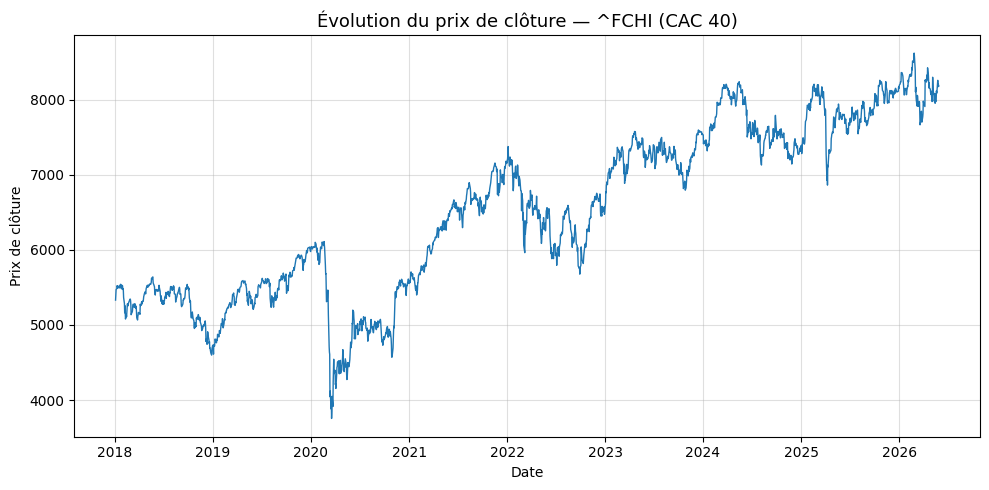

In [4]:
# Graphique 1 — Prix de clôture
plt.figure(figsize=(10, 5))
plt.plot(data.index, data["Close"], color="#1f77b4", linewidth=1)
plt.title(f"Évolution du prix de clôture — {ticker} (CAC 40)", fontsize=13)
plt.xlabel("Date")
plt.ylabel("Prix de clôture")
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

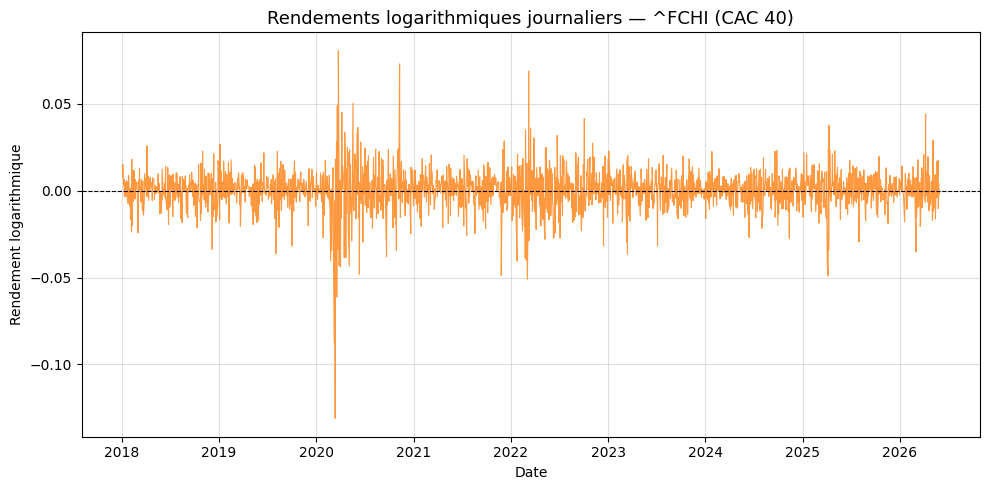

In [5]:
# Graphique 2 — Rendements logarithmiques
plt.figure(figsize=(10, 5))
plt.plot(data.index, data["log_return"], color="#ff7f0e", linewidth=0.8, alpha=0.8)
plt.axhline(0, color="black", linewidth=0.8, linestyle="--")
plt.title(f"Rendements logarithmiques journaliers — {ticker} (CAC 40)", fontsize=13)
plt.xlabel("Date")
plt.ylabel("Rendement logarithmique")
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

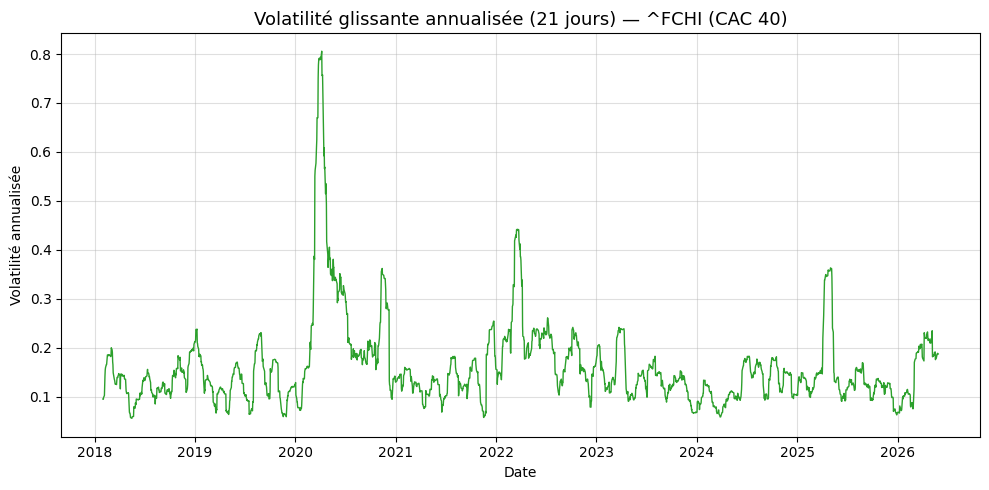

In [6]:
# Graphique 3 — Volatilité glissante annualisée (fenêtre 21 jours)
plt.figure(figsize=(10, 5))
plt.plot(data.index, data["rolling_vol_21"], color="#2ca02c", linewidth=1)
plt.title(f"Volatilité glissante annualisée (21 jours) — {ticker} (CAC 40)", fontsize=13)
plt.xlabel("Date")
plt.ylabel("Volatilité annualisée")
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

Le prix de clôture montre une chute brutale en mars 2020, suivie d'une reprise progressive. 
Les rendements logarithmiques confirment cette période de stress : les amplitudes sont nettement plus grandes qu'en temps normal. 
La volatilité glissante le quantifie clairement, avec un pic dépassant 60 % annualisé lors du choc Covid. 
Ce phénomène est appelé *volatility clustering* : les périodes agitées se regroupent dans le temps. 
C'est une limite bien connue des modèles à volatilité constante comme le CRR.

# Extraction du prix initial et des rendements

$S_0$ est le dernier prix de clôture disponible dans la série. Les rendements logarithmiques sont calculés sur l'ensemble de la période et servent à estimer la volatilité historique.

In [7]:
S0, log_returns = get_S0_and_log_returns(data)

print(f"Prix initial S0           : {S0:.4f}")
print(f"Nombre de rendements log  : {len(log_returns)}")
print(f"Rendement moyen journalier: {log_returns.mean():.6f}")
print(f"Écart-type journalier     : {log_returns.std():.6f}")

Prix initial S0           : 8183.3398
Nombre de rendements log  : 2150
Rendement moyen journalier: 0.000203
Écart-type journalier     : 0.011596


Le vecteur `log_returns` contient tous les rendements journaliers. C'est à partir de ces données que la volatilité sera estimée dans la section suivante.

# Définition de l'option

On définit une option **call européenne at-the-money** : le strike est égal au prix actuel du sous-jacent ($K = S_0$), ce qui signifie que l'option n'est ni dans la monnaie ni en dehors. Une option européenne ne peut s'exercer qu'à maturité.

La maturité d'un an est un choix pédagogique classique, cohérent avec une volatilité exprimée en base annuelle.

In [8]:
strike = S0          # option at-the-money
maturity = 1.0       # maturité d'un an
option_type = "call" # option call

option = Option(
    strike=strike,
    maturity=maturity,
    option_type=option_type
)

print(option)
print(f"\nPayoff si S_T = {S0 * 1.1:.2f} (hausse 10 %) : {option.payoff(S0 * 1.1):.4f}")
print(f"Payoff si S_T = {S0 * 0.9:.2f} (baisse 10 %) : {option.payoff(S0 * 0.9):.4f}")

# Pour tester un put, décommenter la ligne suivante :
# option = Option(strike=S0, maturity=1.0, option_type="put")

Option(type='call', strike=8183.33984375, maturity=1.0)

Payoff si S_T = 9001.67 (hausse 10 %) : 818.3340
Payoff si S_T = 7365.01 (baisse 10 %) : 0.0000


# Calibration des paramètres CRR

Le modèle CRR est paramétré par quatre grandeurs construites à partir de la volatilité $\sigma$, du pas de temps $\Delta t = T/n$ et du taux sans risque $r$ :

$$u = e^{\sigma\sqrt{\Delta t}}, \quad d = e^{-\sigma\sqrt{\Delta t}}, \quad p^* = \frac{e^{r\Delta t} - d}{u - d}$$

Le taux sans risque est fixé à $r = 2\%$, ce qui correspond à un niveau raisonnable pour un marché européen récent. On peut tester 1 % et 3 % dans l'analyse de sensibilité.

La probabilité risque-neutre $p^*$ doit vérifier $0 \leq p^* \leq 1$ pour que le modèle soit sans arbitrage.

In [9]:
n_steps = 100
risk_free_rate = 0.02  # taux sans risque fixé à 2 % par an

params = calibrate_crr_parameters(
    log_returns=log_returns,
    maturity=option.maturity,
    n_steps=n_steps,
    risk_free_rate=risk_free_rate
)

print("=" * 45)
print("  Paramètres calibrés du modèle CRR")
print("=" * 45)
print(f"  Volatilité annualisée σ : {params['sigma']:.4f}  ({params['sigma']*100:.2f} %)")
print(f"  Taux sans risque r      : {params['r']:.4f}  ({params['r']*100:.2f} %)")
print(f"  Pas de temps Δt         : {params['dt']:.6f}")
print(f"  Facteur de hausse u     : {params['u']:.6f}")
print(f"  Facteur de baisse d     : {params['d']:.6f}")
print(f"  Probabilité risque-neutre p* : {params['p_star']:.6f}")
print("=" * 45)

# Vérification de la condition d'absence d'arbitrage
assert 0 < params['p_star'] < 1, "Condition d'absence d'arbitrage non vérifiée !"
print("\n✓ Condition d'absence d'arbitrage vérifiée : 0 < p* < 1")

  Paramètres calibrés du modèle CRR
  Volatilité annualisée σ : 0.1841  (18.41 %)
  Taux sans risque r      : 0.0200  (2.00 %)
  Pas de temps Δt         : 0.010000
  Facteur de hausse u     : 1.018579
  Facteur de baisse d     : 0.981760
  Probabilité risque-neutre p* : 0.500830

✓ Condition d'absence d'arbitrage vérifiée : 0 < p* < 1


# Intervalle de confiance sur la volatilité

La volatilité est estimée à partir de données historiques. Cette estimation est entachée d'une incertitude statistique, que l'intervalle de confiance permet de quantifier. Un intervalle plus étroit indique une estimation plus précise, mais ne garantit pas que la volatilité future restera dans ces bornes.

Volatilité estimée σ̂         : 0.1841  (18.41 %)
Borne inférieure IC à 95 %   : 0.1787  (17.87 %)
Borne supérieure IC à 95 %   : 0.1898  (18.98 %)

Largeur de l'intervalle      : 0.0110


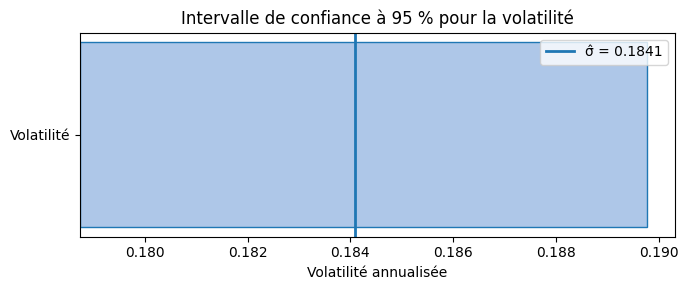

In [10]:
ci_low, ci_high = volatility_confidence_interval(log_returns, confidence_level=0.95)

print(f"Volatilité estimée σ̂         : {params['sigma']:.4f}  ({params['sigma']*100:.2f} %)")
print(f"Borne inférieure IC à 95 %   : {ci_low:.4f}  ({ci_low*100:.2f} %)")
print(f"Borne supérieure IC à 95 %   : {ci_high:.4f}  ({ci_high*100:.2f} %)")
print(f"\nLargeur de l'intervalle      : {(ci_high - ci_low):.4f}")

# Visualisation de l'intervalle
fig, ax = plt.subplots(figsize=(7, 3))
ax.barh(["Volatilité"], [ci_high - ci_low], left=ci_low, color="#aec7e8", edgecolor="#1f77b4", height=0.3)
ax.axvline(params['sigma'], color="#1f77b4", linewidth=2, label=f"σ̂ = {params['sigma']:.4f}")
ax.set_xlabel("Volatilité annualisée")
ax.set_title("Intervalle de confiance à 95 % pour la volatilité")
ax.legend()
plt.tight_layout()
plt.show()

Plus l'échantillon est grand, plus l'intervalle est étroit. L'incertitude sur $\sigma$ se propage directement sur le prix théorique — c'est une motivation pour l'analyse de sensibilité à la volatilité.

# Prix de l'option

Le modèle CRR fonctionne en deux étapes. D'abord, on construit l'arbre des prix du sous-jacent en appliquant les facteurs $u$ et $d$ à chaque nœud. Ensuite, on remonte l'arbre par **rétropropagation** : à partir des payoffs terminaux, on actualise les valeurs espérées sous la mesure risque-neutre :

$$V_i^j = e^{-r\Delta t}\left[p^* V_{i+1}^{j+1} + (1-p^*) V_{i+1}^j\right]$$

Le prix de l'option est la valeur au nœud racine $V_0^0$.

In [11]:
price, value_tree = crr_price(
    S0=S0,
    option=option,
    u=params["u"],
    d=params["d"],
    r=params["r"],
    dt=params["dt"],
    p_star=params["p_star"],
    american=False
)

print("=" * 50)
print(f"  Prix CRR de l'option (européenne) : {price:.4f}")
print("=" * 50)
print(f"\n  Paramètres utilisés :")
print(f"    S0     = {S0:.2f}")
print(f"    Strike = {option.strike:.2f}  (ATM)")
print(f"    T      = {option.maturity} an")
print(f"    σ      = {params['sigma']:.4f}")
print(f"    r      = {params['r']:.4f}")
print(f"    n      = {n_steps} étapes")

  Prix CRR de l'option (européenne) : 677.2185

  Paramètres utilisés :
    S0     = 8183.34
    Strike = 8183.34  (ATM)
    T      = 1.0 an
    σ      = 0.1841
    r      = 0.0200
    n      = 100 étapes


In [12]:
# Prix call américain + puts européen et américain
price_am, _ = crr_price(
    S0=S0, option=option,
    u=params["u"], d=params["d"], r=params["r"],
    dt=params["dt"], p_star=params["p_star"],
    american=True
)

option_put = Option(strike=strike, maturity=maturity, option_type="put")

price_put_eur, _ = crr_price(
    S0=S0, option=option_put,
    u=params["u"], d=params["d"], r=params["r"],
    dt=params["dt"], p_star=params["p_star"],
    american=False
)
price_put_am, _ = crr_price(
    S0=S0, option=option_put,
    u=params["u"], d=params["d"], r=params["r"],
    dt=params["dt"], p_star=params["p_star"],
    american=True
)

print(f"Call européen  : {price:.4f}")
print(f"Call américain : {price_am:.4f}")
print(f"Prime call     : {price_am - price:.4f}")
print()
print(f"Put européen   : {price_put_eur:.4f}")
print(f"Put américain  : {price_put_am:.4f}")
print(f"Prime put      : {price_put_am - price_put_eur:.4f}")

Call européen  : 677.2185
Call américain : 677.2185
Prime call     : 0.0000

Put européen   : 515.1775
Put américain  : 530.2504
Prime put      : 15.0729


Pour un call américain sans dividendes, l'exercice anticipé n'est généralement pas optimal. Le prix américain est donc souvent égal au prix européen. Pour un put en revanche, l'exercice anticipé peut avoir de la valeur quand l'option est très dans la monnaie : la prime d'exercice anticipé du put peut donc être positive.

# Arbre binomial

L'arbre est limité à 5 étapes pour rester lisible. Les paramètres $u$ et $d$ sont recalculés avec un pas de temps adapté à cet affichage : $\Delta t = T / 5$. On ne réutilise pas les paramètres calibrés pour 100 étapes, qui correspondent à un $\Delta t$ différent.

In [13]:
small_n_steps = 5

small_dt = option.maturity / small_n_steps
small_u, small_d = compute_ud(params["sigma"], small_dt)
small_p_star = compute_risk_neutral_probability(
    params["r"], small_dt, small_u, small_d
)

print(f"Paramètres pour l'arbre à {small_n_steps} étapes :")
print(f"  Δt    = {small_dt:.4f}")
print(f"  u     = {small_u:.4f}")
print(f"  d     = {small_d:.4f}")
print(f"  p*    = {small_p_star:.4f}")

price_tree = build_price_tree(S0=S0, u=small_u, d=small_d, n_steps=small_n_steps)

# Affichage sous forme de DataFrame
tree_df = pd.DataFrame(
    [pd.Series(level) for level in price_tree]
)
tree_df.index.name = "Étape"
tree_df.columns = [f"Nœud {j}" for j in tree_df.columns]
tree_df.round(2)

Paramètres pour l'arbre à 5 étapes :
  Δt    = 0.2000
  u     = 1.0858
  d     = 0.9210
  p*    = 0.5037


,Nœud 0,Nœud 1,Nœud 2,Nœud 3,Nœud 4,Nœud 5
Étape,,,,,,
0,8183.34,NaN,NaN,NaN,NaN,NaN
1,7536.62,8885.55,NaN,NaN,NaN,NaN
2,6941.01,8183.34,9648.02,NaN,NaN,NaN
3,6392.47,7536.62,8885.55,10475.92,NaN,NaN
4,5887.29,6941.01,8183.34,9648.02,11374.86,NaN
5,5422.02,6392.47,7536.62,8885.55,10475.92,12350.94


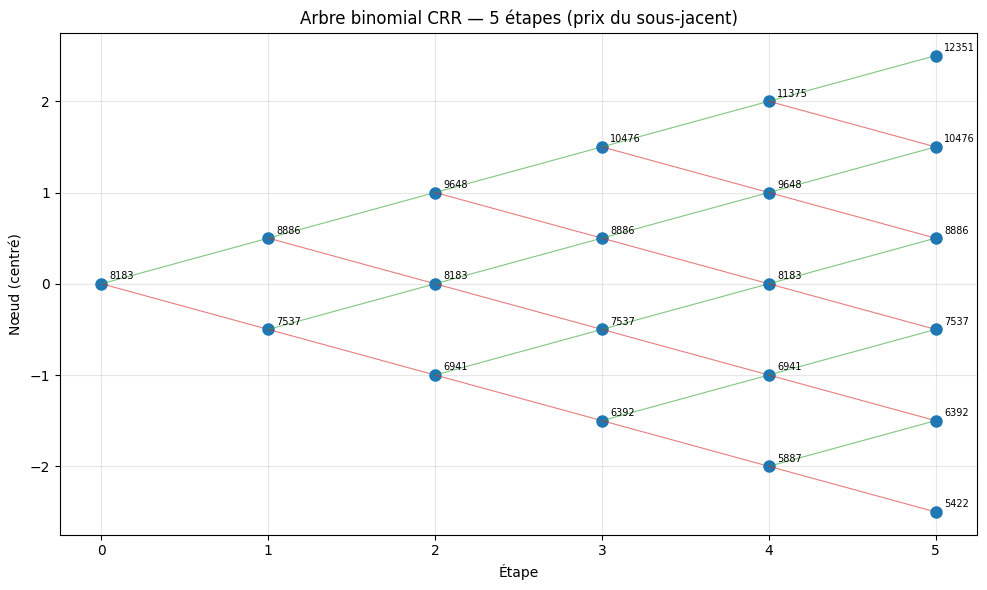

In [14]:
# Représentation graphique de l'arbre (5 étapes)
fig, ax = plt.subplots(figsize=(10, 6))

for i, level in enumerate(price_tree):
    for j, price_node in enumerate(level):
        x = i
        y = j - i / 2  # centrage vertical
        ax.plot(x, y, 'o', color='#1f77b4', markersize=8)
        ax.text(x + 0.05, y + 0.05, f"{price_node:.0f}", fontsize=7, ha='left')
        # Liaisons vers l'étape suivante
        if i < small_n_steps:
            next_level = price_tree[i + 1]
            # branche hausse
            y_up = (j + 1) - (i + 1) / 2
            ax.plot([x, x + 1], [y, y_up], '-', color='#2ca02c', linewidth=0.8, alpha=0.6)
            # branche baisse
            y_dn = j - (i + 1) / 2
            ax.plot([x, x + 1], [y, y_dn], '-', color='#d62728', linewidth=0.8, alpha=0.6)

ax.set_title(f"Arbre binomial CRR — {small_n_steps} étapes (prix du sous-jacent)", fontsize=12)
ax.set_xlabel("Étape")
ax.set_ylabel("Nœud (centré)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Chaque nœud $(i, j)$ représente le prix $S_0 \cdot u^j \cdot d^{i-j}$ après $i$ périodes, avec $j$ hausses et $i-j$ baisses. L'arbre est **recombinable** : hausse puis baisse mène au même nœud que baisse puis hausse. Cela ramène la complexité de $2^n$ à $\mathcal{O}(n^2)$.

# Analyse de sensibilité

On étudie l'impact des trois paramètres principaux sur le prix de l'option : le nombre d'étapes, le strike et la volatilité.

## Nombre d'étapes $n$

Quand $n$ augmente, le modèle CRR approche le prix de Black-Scholes. On vérifie ici la vitesse de convergence.

In [15]:
steps_list = [5, 10, 25, 50, 100, 200, 500]
prices_by_steps = []

for steps in steps_list:
    params_steps = calibrate_crr_parameters(
        log_returns=log_returns,
        maturity=option.maturity,
        n_steps=steps,
        risk_free_rate=risk_free_rate
    )
    price_steps, _ = crr_price(
        S0=S0,
        option=option,
        u=params_steps["u"],
        d=params_steps["d"],
        r=params_steps["r"],
        dt=params_steps["dt"],
        p_star=params_steps["p_star"],
        american=False
    )
    prices_by_steps.append(price_steps)

sensitivity_steps = pd.DataFrame({"n_steps": steps_list, "option_price": prices_by_steps})
print(sensitivity_steps.to_string(index=False))

 n_steps  option_price
       5    708.245282
      10    663.979382
      25    684.541219
      50    675.730249
     100    677.218536
     200    677.964140
     500    678.411960


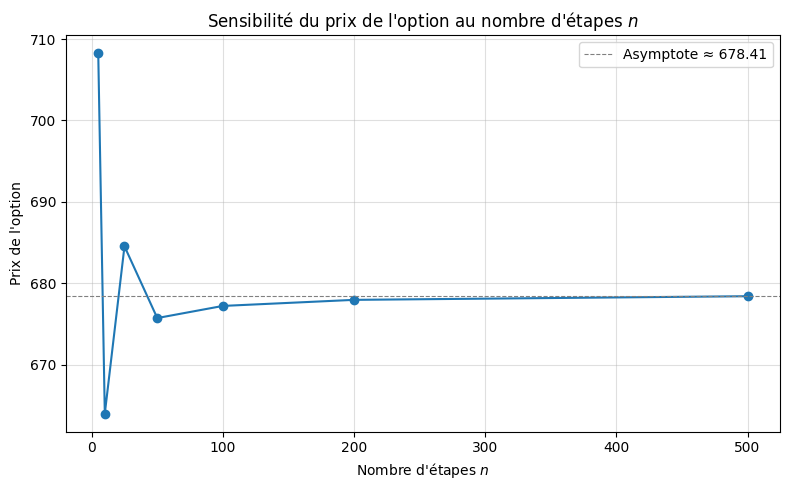

In [16]:
plt.figure(figsize=(8, 5))
plt.plot(sensitivity_steps["n_steps"], sensitivity_steps["option_price"],
         marker="o", color="#1f77b4")
plt.axhline(sensitivity_steps["option_price"].iloc[-1], color="gray",
            linestyle="--", linewidth=0.8, label=f"Asymptote ≈ {sensitivity_steps['option_price'].iloc[-1]:.2f}")
plt.title("Sensibilité du prix de l'option au nombre d'étapes $n$", fontsize=12)
plt.xlabel("Nombre d'étapes $n$")
plt.ylabel("Prix de l'option")
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

Le prix oscille légèrement pour les faibles valeurs de $n$, puis se stabilise à partir de $n \approx 50$. Au-delà de 100 étapes, le gain de précision est marginal.

## Strike $K$

Pour un call, plus le strike est élevé, plus le seuil à franchir est haut, et donc moins l'option a de valeur. On s'attend à une relation décroissante.

In [17]:
strike_values = [0.8 * S0, 0.9 * S0, S0, 1.1 * S0, 1.2 * S0]
prices_by_strike = []

for K in strike_values:
    opt_K = Option(strike=K, maturity=maturity, option_type=option_type)
    price_K, _ = crr_price(
        S0=S0, option=opt_K,
        u=params["u"], d=params["d"],
        r=params["r"], dt=params["dt"],
        p_star=params["p_star"], american=False
    )
    prices_by_strike.append(price_K)

sensitivity_strike = pd.DataFrame({
    "strike": [round(k, 2) for k in strike_values],
    "moneyness": ["ITM -20%", "ITM -10%", "ATM", "OTM +10%", "OTM +20%"],
    "option_price": prices_by_strike
})
print(sensitivity_strike.to_string(index=False))

 strike moneyness  option_price
6546.67  ITM -20%   1823.675241
7365.01  ITM -10%   1172.321420
8183.34       ATM    677.218536
9001.67  OTM +10%    356.010803
9820.01  OTM +20%    168.071589


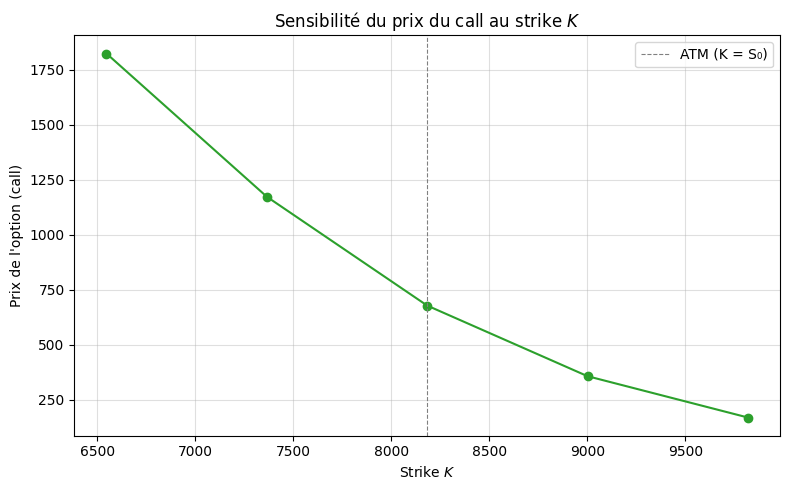

In [18]:
plt.figure(figsize=(8, 5))
plt.plot(sensitivity_strike["strike"], sensitivity_strike["option_price"],
         marker="o", color="#2ca02c")
plt.axvline(S0, color="gray", linestyle="--", linewidth=0.8, label="ATM (K = S₀)")
plt.title("Sensibilité du prix du call au strike $K$", fontsize=12)
plt.xlabel("Strike $K$")
plt.ylabel("Prix de l'option (call)")
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

Le prix du call est bien décroissant avec le strike. Une option fortement dans la monnaie ($K = 0.8 S_0$) a une valeur élevée ; une option très hors de la monnaie ($K = 1.2 S_0$) en a une faible.

## Volatilité $\sigma$

La volatilité augmente l'incertitude sur le prix futur du sous-jacent. Pour une option, cette incertitude est favorable : les gains potentiels sont illimités, les pertes bornées au prix payé.

In [19]:
sigma_values = np.linspace(0.5 * params["sigma"], 1.5 * params["sigma"], 20)
prices_by_sigma = []

for sigma in sigma_values:
    u_s, d_s = compute_ud(sigma, params["dt"])
    p_s = compute_risk_neutral_probability(params["r"], params["dt"], u_s, d_s)
    price_s, _ = crr_price(
        S0=S0, option=option,
        u=u_s, d=d_s, r=params["r"],
        dt=params["dt"], p_star=p_s, american=False
    )
    prices_by_sigma.append(price_s)

sensitivity_sigma = pd.DataFrame({
    "sigma": sigma_values,
    "option_price": prices_by_sigma
})

<>:6: SyntaxWarning: invalid escape sequence '\s'
<>:7: SyntaxWarning: invalid escape sequence '\s'
<>:6: SyntaxWarning: invalid escape sequence '\s'
<>:7: SyntaxWarning: invalid escape sequence '\s'
C:\Users\flavi\AppData\Local\Temp\ipykernel_37792\2893093598.py:6: SyntaxWarning: invalid escape sequence '\s'
  plt.title("Sensibilité du prix de l'option à la volatilité $\sigma$", fontsize=12)
C:\Users\flavi\AppData\Local\Temp\ipykernel_37792\2893093598.py:7: SyntaxWarning: invalid escape sequence '\s'
  plt.xlabel("Volatilité annualisée $\sigma$")


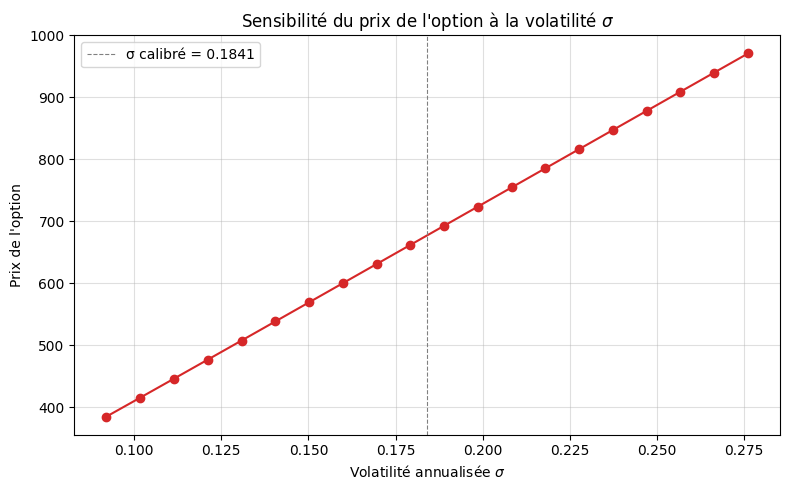

In [20]:
plt.figure(figsize=(8, 5))
plt.plot(sensitivity_sigma["sigma"], sensitivity_sigma["option_price"],
         marker="o", color="#d62728")
plt.axvline(params["sigma"], color="gray", linestyle="--", linewidth=0.8,
            label=f"σ calibré = {params['sigma']:.4f}")
plt.title("Sensibilité du prix de l'option à la volatilité $\sigma$", fontsize=12)
plt.xlabel("Volatilité annualisée $\sigma$")
plt.ylabel("Prix de l'option")
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

La relation est strictement croissante. Doubler la volatilité augmente sensiblement le prix de l'option. Ce résultat est cohérent avec le concept de *vega* en finance.

# Backtest

Le backtest applique le modèle de façon glissante sur l'ensemble de la série. À chaque date, la volatilité est recalibrée sur une fenêtre de 252 jours, puis le prix de l'option est calculé. L'objectif est d'observer la stabilité des paramètres dans le temps, en l'absence de prix d'options de marché disponibles pour comparaison directe.

In [21]:
results = run_backtest(
    data=data,
    option=option,
    pricing_function=crr_price,
    calibration_function=calibrate_crr_parameters,
    n_steps=100,
    risk_free_rate=risk_free_rate,
    window=252
)

print(f"Nombre de dates de test : {len(results)}")
print(f"Période : {results['date'].min().date()} → {results['date'].max().date()}")
results.head()

Nombre de dates de test : 1898
Période : 2018-12-28 → 2026-05-29


,date,S,prix_prédit,sigma,r,dt,u,d,p_star
0,2018-12-28,4678.740234,0.006236,0.137044,0.02,0.01,1.013799,0.986389,0.503871
1,2018-12-31,4730.689941,0.009905,0.137934,0.02,0.01,1.013889,0.986301,0.503802
2,2019-01-02,4689.390137,0.007009,0.137504,0.02,0.01,1.013845,0.986344,0.503835
3,2019-01-03,4611.490234,0.003761,0.137302,0.02,0.01,1.013825,0.986364,0.503851
4,2019-01-04,4737.120117,0.010965,0.138197,0.02,0.01,1.013916,0.986275,0.503782


In [22]:
results.tail()

,date,S,prix_prédit,sigma,r,dt,u,d,p_star
1893,2026-05-25,8258.259766,585.790310,0.140782,0.02,0.01,1.014178,0.986020,0.503584
1894,2026-05-26,8173.109863,536.610227,0.141741,0.02,0.01,1.014275,0.985926,0.503512
1895,2026-05-27,8207.889648,558.709167,0.142131,0.02,0.01,1.014315,0.985887,0.503483
1896,2026-05-28,8188.870117,546.889350,0.142138,0.02,0.01,1.014315,0.985887,0.503483
1897,2026-05-29,8183.339844,543.468599,0.142145,0.02,0.01,1.014316,0.985886,0.503482


In [23]:
summary = summarize_backtest_results(results)

print("=" * 45)
print("  Résumé du backtest")
print("=" * 45)
for k, v in summary.items():
    if isinstance(v, float):
        print(f"  {k:<30} : {v:.4f}")
    else:
        print(f"  {k:<30} : {v}")
print("=" * 45)

  Résumé du backtest
  n_observations                 : 1898
  prix_moyen_predit              : 185.5474
  prix_min_predit                : 0.0038
  prix_max_predit                : 864.3058
  sigma_moyen                    : 0.1795
  p_star_moyen                   : 0.5016
  n_nan                          : 0


In [24]:
stability = analyze_stability(results)

print("Statistiques de volatilité calibrée :")
for k, v in stability["sigma_stats"].items():
    print(f"  {k:<20} : {v:.4f}")

print("\nStatistiques de p* :")
for k, v in stability["p_star_stats"].items():
    print(f"  {k:<20} : {v:.6f}")

Statistiques de volatilité calibrée :
  sigma_moyen          : 0.1795
  sigma_min            : 0.1151
  sigma_max            : 0.3303
  sigma_std            : 0.0592

Statistiques de p* :
  p_star_moyen         : 0.501575
  p_star_std           : 0.002992


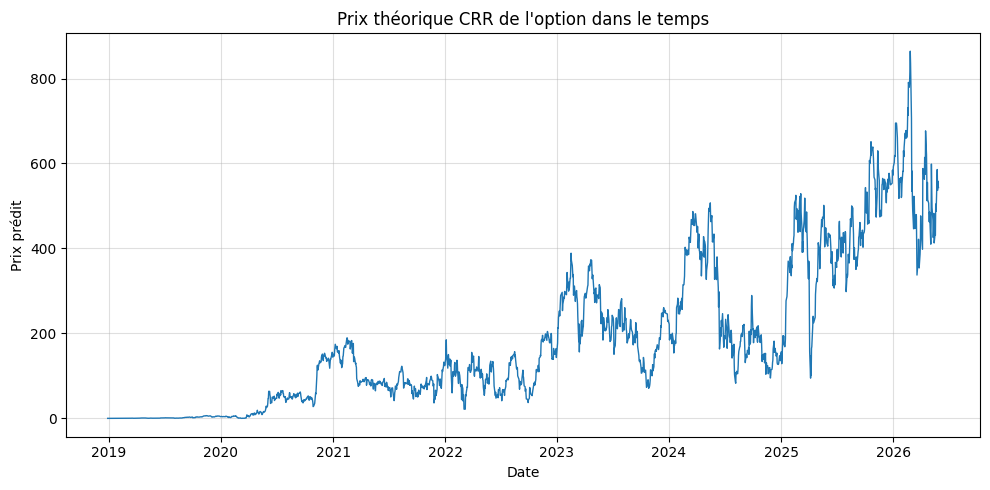

In [25]:
# 12.1 — Prix prédit de l'option dans le temps
plt.figure(figsize=(10, 5))
plt.plot(results["date"], results["prix_prédit"], color="#1f77b4", linewidth=1)
plt.title("Prix théorique CRR de l'option dans le temps", fontsize=12)
plt.xlabel("Date")
plt.ylabel("Prix prédit")
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

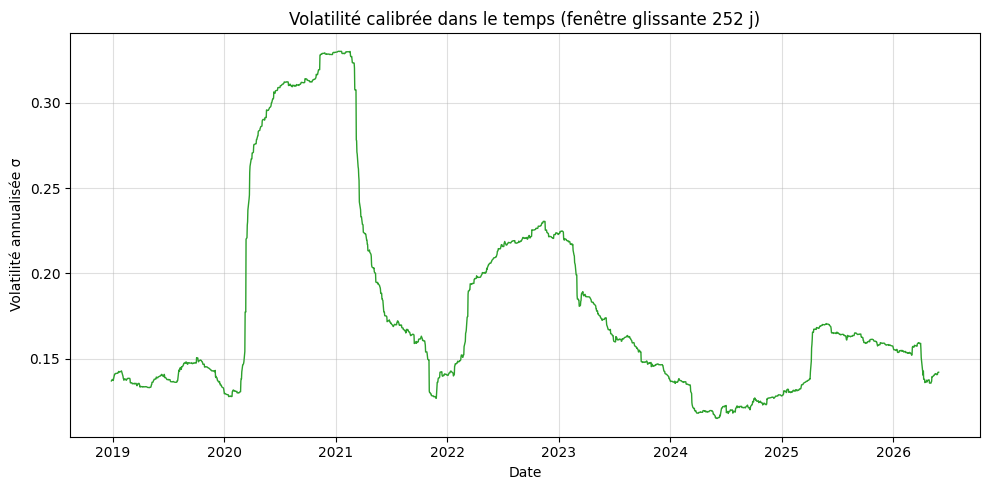

In [26]:
# 12.2 — Volatilité calibrée dans le temps
plt.figure(figsize=(10, 5))
plt.plot(results["date"], results["sigma"], color="#2ca02c", linewidth=1)
plt.title("Volatilité calibrée dans le temps (fenêtre glissante 252 j)", fontsize=12)
plt.xlabel("Date")
plt.ylabel("Volatilité annualisée σ")
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

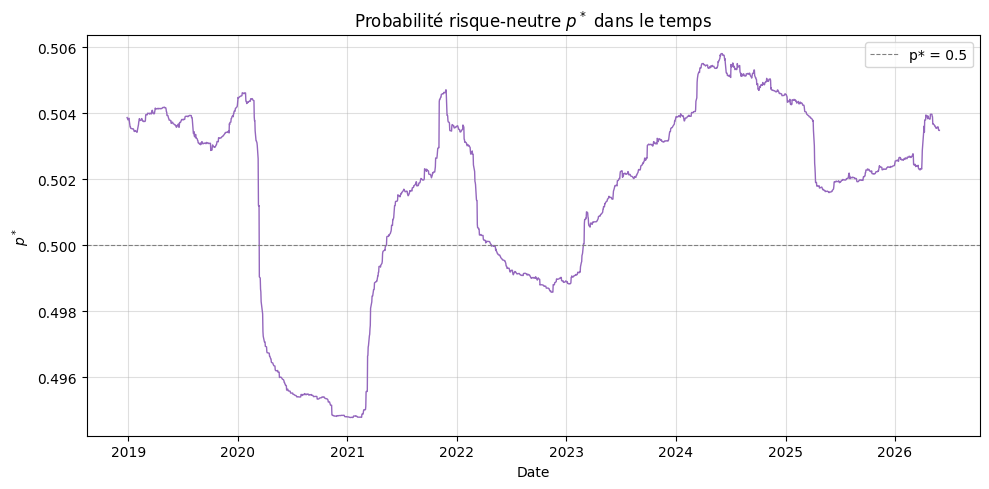

In [27]:
# 12.3 — Probabilité risque-neutre p* dans le temps
plt.figure(figsize=(10, 5))
plt.plot(results["date"], results["p_star"], color="#9467bd", linewidth=1)
plt.axhline(0.5, color="gray", linestyle="--", linewidth=0.8, label="p* = 0.5")
plt.title("Probabilité risque-neutre $p^*$ dans le temps", fontsize=12)
plt.xlabel("Date")
plt.ylabel("$p^*$")
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

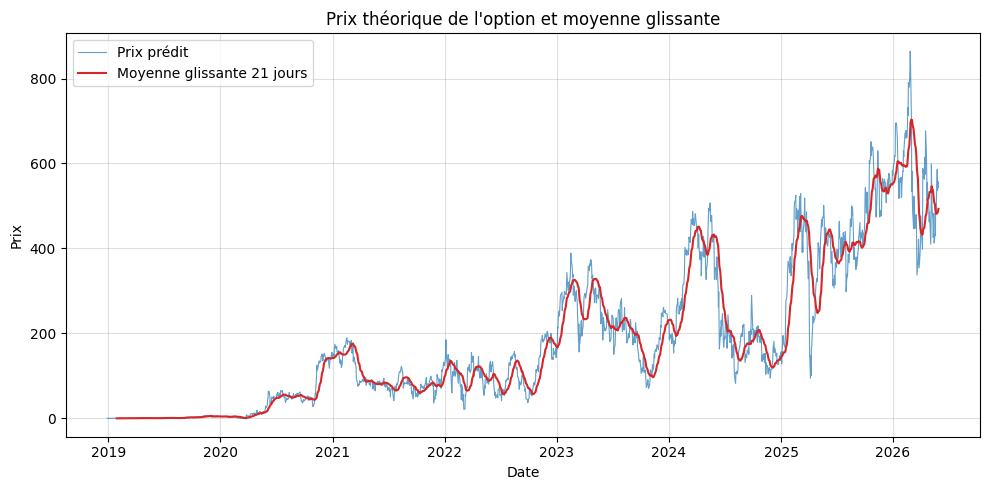

In [28]:
# 12.4 — Prix prédit et moyenne glissante 21 jours
serie_temporelle = stability["serie_temporelle"]

plt.figure(figsize=(10, 5))
plt.plot(serie_temporelle["date"], serie_temporelle["prix_prédit"],
         color="#1f77b4", linewidth=0.8, alpha=0.7, label="Prix prédit")
plt.plot(serie_temporelle["date"], serie_temporelle["rolling_mean_prix"],
         color="#d62728", linewidth=1.5, label="Moyenne glissante 21 jours")
plt.title("Prix théorique de l'option et moyenne glissante", fontsize=12)
plt.xlabel("Date")
plt.ylabel("Prix")
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

Le prix prédit suit le prix du sous-jacent et la volatilité recalibrée : les pics de prix correspondent aux périodes de forte volatilité. La volatilité n'est clairement pas constante dans le temps — elle présente des régimes distincts, ce que le modèle CRR dans sa version de base ne capture pas. La probabilité risque-neutre $p^*$ reste proche de 0.5 tout au long de la période, ce qui reflète la stabilité structurelle du modèle.

# Comparaison CAC 40 et Brent

On applique la même méthode aux deux actifs du sujet : l'indice CAC 40 et le Brent. La comparaison permet d'observer comment une différence de volatilité se répercute sur les paramètres CRR et les prix d'options.

In [29]:
assets = {
    "CAC40": "^FCHI",
    "Brent": "BZ=F"
}

start_date = "2018-01-01"
end_date   = "2026-06-01"
maturity   = 1.0
n_steps    = 100
risk_free_rate = 0.02

comparison_rows = []

for name, ticker_cmp in assets.items():
    data_cmp = build_dataset(ticker_cmp, start_date, end_date)
    S0_cmp, lr_cmp = get_S0_and_log_returns(data_cmp)

    params_cmp = calibrate_crr_parameters(
        log_returns=lr_cmp,
        maturity=maturity,
        n_steps=n_steps,
        risk_free_rate=risk_free_rate
    )
    ci_lo, ci_hi = volatility_confidence_interval(lr_cmp, confidence_level=0.95)

    opt_call = Option(strike=S0_cmp, maturity=maturity, option_type="call")
    opt_put  = Option(strike=S0_cmp, maturity=maturity, option_type="put")

    def _price(opt, am):
        p, _ = crr_price(
            S0=S0_cmp, option=opt,
            u=params_cmp["u"], d=params_cmp["d"],
            r=params_cmp["r"], dt=params_cmp["dt"],
            p_star=params_cmp["p_star"], american=am
        )
        return p

    ce = _price(opt_call, False)
    ca = _price(opt_call, True)
    pe = _price(opt_put,  False)
    pa = _price(opt_put,  True)

    comparison_rows.append({
        "Actif": name,
        "S0": round(S0_cmp, 2),
        "sigma": round(params_cmp["sigma"], 4),
        "IC bas 95%": round(ci_lo, 4),
        "IC haut 95%": round(ci_hi, 4),
        "u": round(params_cmp["u"], 4),
        "d": round(params_cmp["d"], 4),
        "p_star": round(params_cmp["p_star"], 4),
        "Call EUR": round(ce, 4),
        "Call AM": round(ca, 4),
        "Put EUR": round(pe, 4),
        "Put AM": round(pa, 4),
        "Prime put": round(pa - pe, 4),
    })

df_comparison = pd.DataFrame(comparison_rows).set_index("Actif")
df_comparison

,S0,sigma,IC bas 95%,IC haut 95%,u,d,p_star,Call EUR,Call AM,Put EUR,Put AM,Prime put
Actif,,,,,,,,,,,,
CAC40,8183.34,0.1841,0.1787,0.1898,1.0186,0.9818,0.5008,677.2185,677.2185,515.1775,530.2504,15.0729
Brent,92.05,0.4187,0.4065,0.4317,1.0428,0.9590,0.4919,16.0044,16.0044,14.1817,14.3524,0.1708


Le Brent est généralement plus volatile que le CAC 40 sur des périodes récentes, ce qui se traduit par des facteurs $u$ et $d$ plus éloignés de 1 et des prix d'options plus élevés. La probabilité risque-neutre $p^*$ reste proche de 0.5 dans les deux cas, ce qui est cohérent. La prime d'exercice anticipé du put est positive ou nulle selon le régime de volatilité : pour un put très dans la monnaie, l'exercice immédiat peut être préférable à l'attente.

# Analyse de plusieurs paramétrages

On étudie l'effet du nombre d'étapes, du taux sans risque et de la maturité sur le prix du call européen. Les calculs sont faits sur le CAC 40 ($S_0$, $\sigma$ calibrés ci-dessus).

## Nombre d'étapes

Quand $n$ augmente, le maillage de l'arbre devient plus fin et le prix converge.

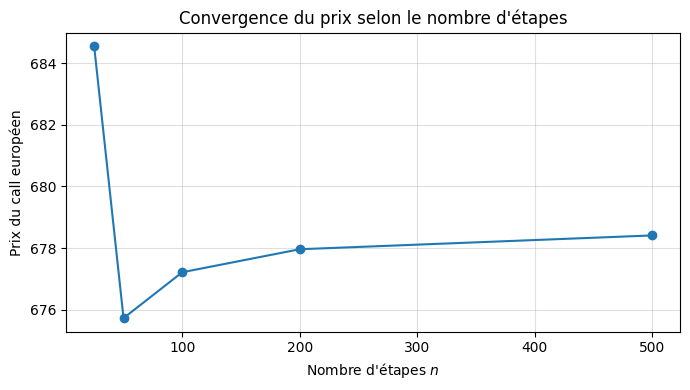

In [30]:
n_steps_values = [25, 50, 100, 200, 500]
prices_n = []
for n in n_steps_values:
    p_n = calibrate_crr_parameters(log_returns=log_returns, maturity=1.0,
                                    n_steps=n, risk_free_rate=0.02)
    opt_tmp = Option(strike=S0, maturity=1.0, option_type="call")
    pr, _ = crr_price(S0=S0, option=opt_tmp,
                      u=p_n["u"], d=p_n["d"], r=p_n["r"],
                      dt=p_n["dt"], p_star=p_n["p_star"], american=False)
    prices_n.append(pr)

plt.figure(figsize=(7, 4))
plt.plot(n_steps_values, prices_n, marker="o", color="#1f77b4")
plt.xlabel("Nombre d'étapes $n$")
plt.ylabel("Prix du call européen")
plt.title("Convergence du prix selon le nombre d'étapes")
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

Le prix se stabilise rapidement. À partir de $n = 100$, les variations sont inférieures à quelques centimes. Un nombre d'étapes élevé améliore la précision mais allonge le temps de calcul.

## Taux sans risque

Un taux plus élevé accroît la valeur actualisée du sous-jacent et donc le prix du call.

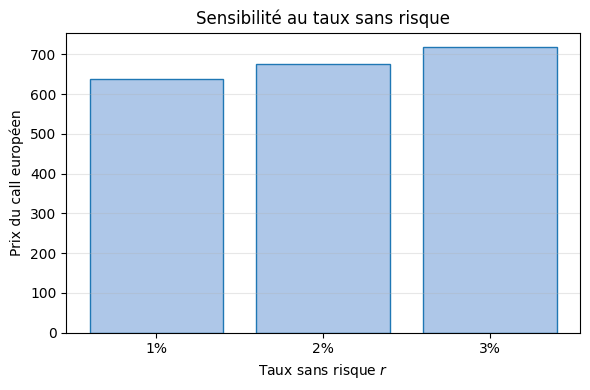

r = 1%  ->  prix = 637.2509
r = 2%  ->  prix = 677.2185
r = 3%  ->  prix = 718.5134


In [31]:
risk_free_rates = [0.01, 0.02, 0.03]
prices_r = []
for r_val in risk_free_rates:
    p_r = calibrate_crr_parameters(log_returns=log_returns, maturity=1.0,
                                    n_steps=100, risk_free_rate=r_val)
    opt_tmp = Option(strike=S0, maturity=1.0, option_type="call")
    pr, _ = crr_price(S0=S0, option=opt_tmp,
                      u=p_r["u"], d=p_r["d"], r=p_r["r"],
                      dt=p_r["dt"], p_star=p_r["p_star"], american=False)
    prices_r.append(pr)

plt.figure(figsize=(6, 4))
plt.bar([str(int(r*100))+"%" for r in risk_free_rates], prices_r, color="#aec7e8", edgecolor="#1f77b4")
plt.xlabel("Taux sans risque $r$")
plt.ylabel("Prix du call européen")
plt.title("Sensibilité au taux sans risque")
plt.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()
for r_val, pr in zip(risk_free_rates, prices_r):
    print(f"r = {r_val:.0%}  ->  prix = {pr:.4f}")

L'effet du taux est modéré sur un horizon d'un an. L'essentiel du prix est porté par la volatilité.

## Maturité

Une maturité plus longue laisse davantage de temps au sous-jacent pour dépasser le strike.

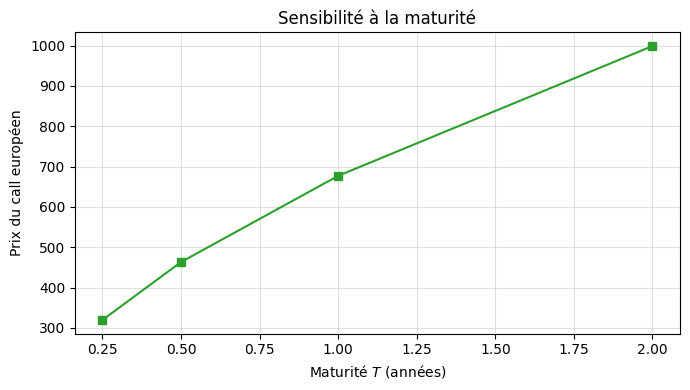

In [32]:
maturities = [0.25, 0.5, 1.0, 2.0]
prices_mat = []
for T in maturities:
    p_T = calibrate_crr_parameters(log_returns=log_returns, maturity=T,
                                    n_steps=100, risk_free_rate=0.02)
    opt_tmp = Option(strike=S0, maturity=T, option_type="call")
    pr, _ = crr_price(S0=S0, option=opt_tmp,
                      u=p_T["u"], d=p_T["d"], r=p_T["r"],
                      dt=p_T["dt"], p_star=p_T["p_star"], american=False)
    prices_mat.append(pr)

plt.figure(figsize=(7, 4))
plt.plot(maturities, prices_mat, marker="s", color="#2ca02c")
plt.xlabel("Maturité $T$ (années)")
plt.ylabel("Prix du call européen")
plt.title("Sensibilité à la maturité")
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

Le prix du call est croissant avec la maturité. Un horizon plus long augmente l'incertitude et donc la valeur de l'option.

# Marché stable et marché instable

Le modèle CRR suppose une volatilité constante sur l'horizon de valorisation. En pratique, les marchés alternent entre périodes calmes et périodes agitées. On compare ici les paramètres calibrés sur deux sous-périodes du CAC 40.

,S0,sigma,IC bas 95%,IC haut 95%,u,d,p_star,Prix call EUR
Période,,,,,,,,
Instable (fév-juin 2020),4935.99,0.4525,0.3982,0.524,1.0463,0.9558,0.4909,922.2301
Stable (2021),7153.03,0.1397,0.1286,0.153,1.0141,0.9861,0.5037,468.3550


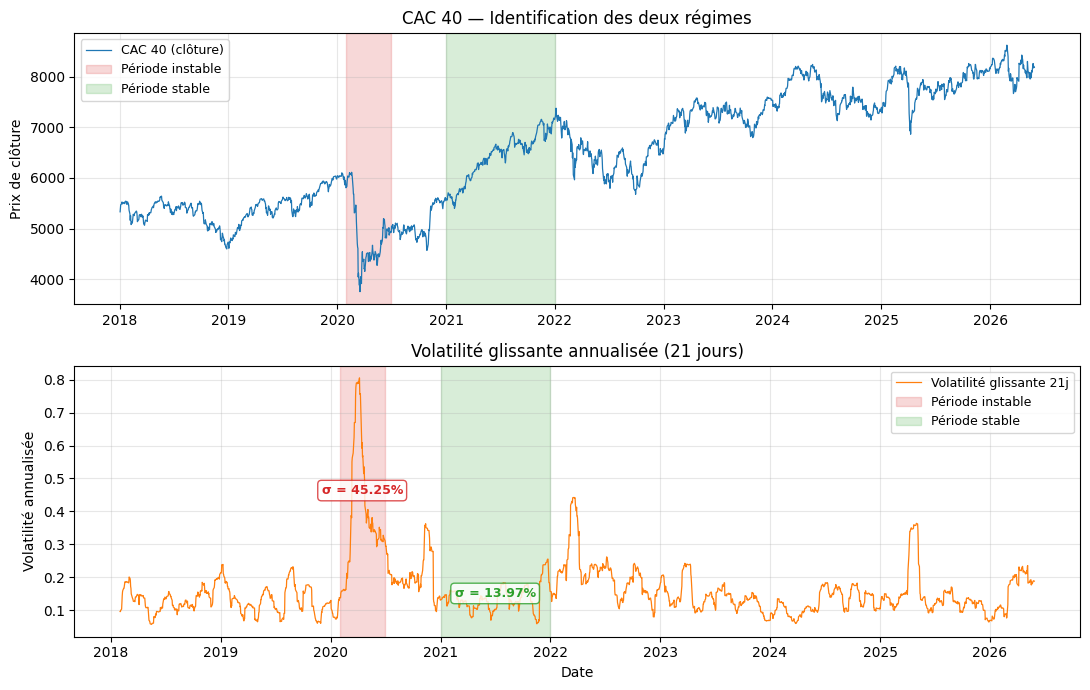

In [33]:
data_cac = build_dataset("^FCHI", "2018-01-01", "2026-06-01")

unstable = data_cac.loc["2020-02-01":"2020-06-30"]
stable   = data_cac.loc["2021-01-01":"2021-12-31"]

regimes = {"Instable (fév-juin 2020)": unstable, "Stable (2021)": stable}
regime_rows = []

for label, subset in regimes.items():
    S0_r, lr_r = get_S0_and_log_returns(subset)
    if len(lr_r) < 30:
        print(f"Données insuffisantes pour {label}")
        continue
    p_r = calibrate_crr_parameters(log_returns=lr_r, maturity=1.0,
                                    n_steps=100, risk_free_rate=0.02)
    ci_lo_r, ci_hi_r = volatility_confidence_interval(lr_r, confidence_level=0.95)
    opt_r = Option(strike=S0_r, maturity=1.0, option_type="call")
    pr_r, _ = crr_price(
        S0=S0_r, option=opt_r,
        u=p_r["u"], d=p_r["d"], r=p_r["r"],
        dt=p_r["dt"], p_star=p_r["p_star"], american=False
    )
    regime_rows.append({
        "Période": label,
        "S0": round(S0_r, 2),
        "sigma": round(p_r["sigma"], 4),
        "IC bas 95%": round(ci_lo_r, 4),
        "IC haut 95%": round(ci_hi_r, 4),
        "u": round(p_r["u"], 4),
        "d": round(p_r["d"], 4),
        "p_star": round(p_r["p_star"], 4),
        "Prix call EUR": round(pr_r, 4)
    })

df_regimes = pd.DataFrame(regime_rows).set_index("Période")
display(df_regimes)

# ---- Graphique ----
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=False)

colors = {"Instable (fév-juin 2020)": "#d62728", "Stable (2021)": "#2ca02c"}
subsets_list = [("Instable (fév-juin 2020)", unstable), ("Stable (2021)", stable)]

# Top panel: prix de clôture sur toute la période avec zones colorées
ax0 = axes[0]
ax0.plot(data_cac.index, data_cac["Close"], color="#1f77b4", linewidth=0.9, label="CAC 40 (clôture)")
ax0.axvspan(pd.Timestamp("2020-02-01"), pd.Timestamp("2020-06-30"),
            alpha=0.18, color="#d62728", label="Période instable")
ax0.axvspan(pd.Timestamp("2021-01-01"), pd.Timestamp("2021-12-31"),
            alpha=0.18, color="#2ca02c", label="Période stable")
ax0.set_title("CAC 40 — Identification des deux régimes", fontsize=12)
ax0.set_ylabel("Prix de clôture")
ax0.legend(fontsize=9)
ax0.grid(True, alpha=0.3)

# Bottom panel: volatilité glissante sur toute la période avec zones colorées
ax1 = axes[1]
ax1.plot(data_cac.index, data_cac["rolling_vol_21"], color="#ff7f0e", linewidth=0.9, label="Volatilité glissante 21j")
ax1.axvspan(pd.Timestamp("2020-02-01"), pd.Timestamp("2020-06-30"),
            alpha=0.18, color="#d62728", label="Période instable")
ax1.axvspan(pd.Timestamp("2021-01-01"), pd.Timestamp("2021-12-31"),
            alpha=0.18, color="#2ca02c", label="Période stable")

# Annotations volatilités estimées
for row in regime_rows:
    label  = row["Période"]
    sigma  = row["sigma"]
    color  = colors[label]
    # position x au milieu de chaque période
    if "2020" in label:
        x_mid = pd.Timestamp("2020-04-15")
    else:
        x_mid = pd.Timestamp("2021-07-01")
    ax1.annotate(f"σ = {sigma:.2%}",
                 xy=(x_mid, sigma),
                 fontsize=9, color=color, fontweight="bold",
                 ha="center",
                 bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=color, alpha=0.8))

ax1.set_title("Volatilité glissante annualisée (21 jours)", fontsize=12)
ax1.set_ylabel("Volatilité annualisée")
ax1.set_xlabel("Date")
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

En période instable, la volatilité estimée est nettement plus élevée. Les facteurs $u$ et $d$ s'écartent davantage de 1, et le prix de l'option augmente fortement. Cette comparaison illustre la sensibilité du modèle au régime de marché : utiliser une volatilité historique calculée en période calme pour valoriser une option en période de crise conduirait à sous-estimer le prix, et inversement.

# Validité du modèle

On examine ici quelques critères permettant de juger de la cohérence du modèle.

**Probabilité risque-neutre.** La valeur de $p^*$ est comprise entre 0 et 1 pour tous les actifs testés, ce qui garantit l'absence d'arbitrage dans l'arbre.

**Stabilité de la volatilité.** Le backtest montre que la volatilité calibrée varie dans le temps. Le modèle utilise une volatilité constante sur chaque valorisation, ce qui est une approximation. En période de forte volatilité, le modèle surestime ou sous-estime le risque selon la fenêtre choisie.

**Cohérence des sensibilités.** Le prix du call est bien décroissant avec le strike, croissant avec la volatilité, la maturité et le taux sans risque. Ces résultats sont conformes à la théorie.

**Convergence numérique.** Le prix se stabilise à partir de $n \approx 100$ étapes. Au-delà, le gain de précision est marginal.

**Absence de prix observés.** Sans prix d'options de marché disponibles, il n'est pas possible de comparer directement le prix théorique au prix réel. Le modèle CRR donne un prix théorique cohérent avec ses hypothèses. Sa validation empirique reste limitée si l'on ne dispose pas de prix d'options observés pour comparer les résultats.

# Table de synthèse

Ce tableau regroupe les résultats principaux pour chaque actif, à maturité 1 an et taux sans risque 2 %.

In [34]:
# On reprend df_comparison et on ajoute les colonnes manquantes
df_synthesis = df_comparison.copy()
df_synthesis.insert(1, "Strike", df_synthesis["S0"])  # ATM : strike = S0
df_synthesis.insert(2, "Maturité", 1.0)
df_synthesis.insert(6, "r", 0.02)
df_synthesis.insert(7, "IC 95%",
    df_synthesis["IC bas 95%"].map(lambda x: f"{x:.4f}") + " / " +
    df_synthesis["IC haut 95%"].map(lambda x: f"{x:.4f}")
)
df_synthesis = df_synthesis.drop(columns=["IC bas 95%", "IC haut 95%"])
df_synthesis

,S0,Strike,Maturité,sigma,r,IC 95%,u,d,p_star,Call EUR,Call AM,Put EUR,Put AM,Prime put
Actif,,,,,,,,,,,,,,
CAC40,8183.34,8183.34,1.0,0.1841,0.02,0.1787 / 0.1898,1.0186,0.9818,0.5008,677.2185,677.2185,515.1775,530.2504,15.0729
Brent,92.05,92.05,1.0,0.4187,0.02,0.4065 / 0.4317,1.0428,0.9590,0.4919,16.0044,16.0044,14.1817,14.3524,0.1708


# Référence

Le modèle binomial a été introduit par J. Cox, S. Ross et M. Rubinstein dans leur article *Option Pricing: A Simplified Approach* (1979). Le cadre théorique de ce projet s'appuie sur la référence [HB16] indiquée dans le sujet.

# Discussion

Le modèle CRR repose sur plusieurs hypothèses simplificatrices. La volatilité est supposée constante sur chaque valorisation, alors que les données réelles montrent de l'hétéroscédasticité marquée. Les rendements sont supposés log-normaux, mais les marchés présentent des queues épaisses et une asymétrie négative : les chocs extrêmes comme mars 2020 sont plus fréquents que ce que la loi normale prédit.

Le taux sans risque est fixé manuellement, alors qu'en pratique il dépend de la maturité et des conditions de marché. Le modèle ignore aussi les coûts de transaction et les dividendes.

Malgré ces limites, le CRR reste utile. L'arbre binomial est lisible et chaque nœud a une interprétation économique claire. La rétropropagation permet de traiter naturellement les options américaines. Et pour $n$ grand, le prix CRR converge vers le prix de Black-Scholes.

Pour aller plus loin, on pourrait utiliser une volatilité implicite plutôt qu'historique, ou introduire un modèle à volatilité stochastique pour mieux capturer le smile de volatilité.

# Conclusion

Ce projet a mis en œuvre le modèle de Cox, Ross et Rubinstein de manière complète. On a récupéré des données réelles pour le CAC 40 et le Brent, estimé la volatilité historique et construit un intervalle de confiance à 95 %. Les paramètres CRR ont été calibrés et le prix d'options européennes et américaines calculé pour les deux actifs. Une comparaison entre régime stable et régime instable a montré l'impact du régime de marché sur la volatilité estimée et les prix obtenus. Plusieurs paramétrages ont été testés : nombre d'étapes, taux sans risque et maturité. Le backtest a permis d'observer la stabilité du modèle dans le temps.

Le modèle CRR fournit un cadre clair pour valoriser des options, mais il reste une approximation des marchés réels.